# 텀 프로젝트: 대중음악 코드 진행 기반 아티스트 스타일 분석 및 유사 아티스트 탐색
### — 화성 데이터를 활용한 내용 기반 추천 시스템의 가능성

**학번**: 20211710  
**이름**: 정은광  

---
## 1. 프로젝트 개요 및 연구 질문
기존의 음악 추천 시스템은 장르, 인기도 등에 주로 의존하며 음악 고유의 구조적 특성을 충분히 반영하지 못하는 한계가 있습니다. 본 프로젝트는 음악의 뼈대인 **코드 진행(Chord Progression)** 데이터를 분석하여, 화성 구조만으로 아티스트의 고유한 스타일을 규명하고 이를 내용 기반(Content-Based) 추천 시스템에 활용할 수 있는지 탐색합니다.

### 핵심 연구 질문
- **Q1. 아티스트마다 고유한 화성 특징이 존재하는가?**
- **Q2. 어떤 화성 특징이 아티스트 스타일을 설명하는 데 중요한 역할을 하는가?**
- **Q3. 코드 진행 특징만으로 유사한 음악적 스타일을 가진 아티스트를 탐색할 수 있는가?**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from music21 import roman, key, harmony
import warnings
import re
import platform
warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
    sns.set_theme(style="whitegrid", font="AppleGothic")
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    sns.set_theme(style="whitegrid", font="Malgun Gothic")
else:
    plt.rcParams['font.family'] = 'NanumGothic'
    sns.set_theme(style="whitegrid", font="NanumGothic")
    
plt.rcParams['axes.unicode_minus'] = False


✅ 모든 라이브러리가 성공적으로 로드되었습니다.


## 2. 데이터 확보 및 수집 (Data Collection)
통계적 유의성을 확보하고 아티스트의 고유 스타일을 추출하기 위해, Hooktheory 데이터베이스에서 **100여 명의 주요 팝 아티스트를 대상으로 아티스트당 최소 5곡 이상, 총 565곡**의 원본 스케일 도수(Scale Index) 데이터를 직접 수집하였습니다.

In [15]:
REAL_DATA_PATH = 'collected_data.csv'
df_songs = pd.read_csv(REAL_DATA_PATH)

df_songs['chord_count'] = df_songs['raw_chords'].apply(lambda x: len(str(x).split()))
before_count = len(df_songs)
df_songs = df_songs[df_songs['chord_count'] >= 4].reset_index(drop=True)
print(f"코드 수 4개 미만 곡 {before_count - len(df_songs)}곡 제외 -> 최종 {len(df_songs)}곡 분석 대상")

modal_to_minor = {'dorian', 'phrygian', 'aeolian'}
def map_key(row):
    mode = str(row.get('mode', 'major')).lower()
    k = row['key']
    return k + 'm' if mode == 'minor' or mode in modal_to_minor else k
df_songs['key'] = df_songs.apply(map_key, axis=1)

코드 수 4개 미만 곡 25곡 제외 -> 최종 540곡 분석 대상


## 3. 데이터 전처리 및 피처 엔지니어링
### 3.1 `music21` 로마숫자 도수 표기 변환
### 3.2 핵심 화성 피처 및 루프(Loop) 지수 추출
- **`feat_brightness` (명도 지수)**: 다이아토닉 메이저 화음의 비율. 1에 가까울수록 밝음.
- **`feat_minor_ratio`**: 마이너 코드 비율.
- **`feat_tension_ratio`**: 7th, 9th 등 텐션 코드 비율.
- **`feat_non_diatonic_ratio`**: 비다이아토닉/차용화음 비율.
- **`feat_step_motion`**: 순차 진행 비율.
- **`feat_leap_motion`**: 도약 진행 비율.
- **`feat_loop_ratio`**: 곡 내에 똑같은 진행 패턴이 얼마나 반복되는지 측정 (대중음악 훅 메이킹 특성).

In [16]:
def clean_chord_for_music21(chord_name):
    c = str(chord_name).split('/')[0]
    c = c.replace('min', 'm').replace('maj', 'Maj')
    return c

def convert_to_roman_numeral(chord_name, key_str):
    is_minor_key = key_str.endswith('m')
    key_name = key_str[:-1].lower() if is_minor_key else key_str.upper()
    try:
        k_obj = key.Key(key_name) if not is_minor_key else key.Key(key_name, 'minor')
        c_clean = clean_chord_for_music21(chord_name)
        cs = harmony.ChordSymbol(c_clean)
        rn = roman.romanNumeralFromChord(cs, k_obj)
        return rn
    except Exception:
        return None

ROMA_TO_DEGREE = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7}
def figure_to_degree(figure):
    if figure is None: return None
    fig_clean = re.sub(r'^[b#]+', '', str(figure))
    match = re.match(r'([IViv]+)', fig_clean)
    if not match: return None
    return ROMA_TO_DEGREE.get(match.group(1).upper())

def extract_base_features_and_sequence(row):
    chords = str(row['raw_chords']).split()
    key_str = str(row['key'])
    is_minor_key = key_str.endswith('m')
    
    unique_chords = len(set(chords))
    feat_unique_chords = unique_chords / len(chords) if len(chords) > 0 else 0
    
    rn_objects = []
    for c in chords:
        rn = convert_to_roman_numeral(c, key_str)
        if rn is not None: rn_objects.append((c, rn))
            
    if len(rn_objects) == 0:
        return pd.Series([0.0, 0.0, 0.0, 0.0, 0.0, []], 
                         index=['feat_unique_chords', 'feat_non_diatonic_ratio', 
                                'feat_minor_ratio', 'feat_tension_ratio', 'feat_brightness', 'rn_sequence'])
        
    major_diatonic = {'I', 'ii', 'iii', 'IV', 'V', 'vi', 'viio', 'vii°'}
    minor_diatonic = {'i', 'iio', 'ii°', 'bIII', 'III', 'iv', 'v', 'V', 'bVI', 'VI', 'bVII', 'VII'}

    non_diatonic_count = 0
    minor_count = 0
    tension_count = 0
    major_diatonic_count = 0
    
    for c_name, rn in rn_objects:
        fig = rn.figure
        if is_minor_key: is_diatonic = any(fig.startswith(d) for d in minor_diatonic)
        else: is_diatonic = any(fig.startswith(d) for d in major_diatonic)

        if not is_diatonic: non_diatonic_count += 1
        if rn.romanNumeralAlone.islower(): minor_count += 1
        
        is_diminished = 'o' in fig or '°' in fig
        if is_diatonic and not rn.romanNumeralAlone.islower() and not is_diminished:
            major_diatonic_count += 1
            
        c_lower = c_name.lower()
        has_tension = any(x in c_lower for x in ['7', '9', '11', '13', 'add', '6'])
        if 'maj' in c_lower: has_tension = has_tension or bool(re.search(r'maj\d', c_lower))
        if has_tension: tension_count += 1
            
    total_rn = len(rn_objects)
    return pd.Series([
        feat_unique_chords,
        non_diatonic_count / total_rn,
        minor_count / total_rn,
        tension_count / total_rn,
        major_diatonic_count / total_rn,
        [rn.figure for _, rn in rn_objects]
    ], index=['feat_unique_chords', 'feat_non_diatonic_ratio', 
              'feat_minor_ratio', 'feat_tension_ratio', 'feat_brightness', 'rn_sequence'])

def extract_progression_features(degree_seq):
    if len(degree_seq) < 2: return {'feat_step_motion': 0.0, 'feat_leap_motion': 0.0, 'feat_loop_ratio': 0.0}
        
    step_count, leap_count = 0, 0
    bigrams = []
    for i in range(len(degree_seq) - 1):
        deg1, deg2 = degree_seq[i], degree_seq[i+1]
        bigrams.append((deg1, deg2))
        diff = abs(deg2 - deg1)
        if diff == 1 or diff == 6: step_count += 1
        elif 2 <= diff <= 5: leap_count += 1
            
    total_tr = len(degree_seq) - 1
    feat_loop_ratio = 1.0 - (len(set(bigrams)) / total_tr) if total_tr > 0 else 0.0
    return {'feat_step_motion': step_count / total_tr, 'feat_leap_motion': leap_count / total_tr, 'feat_loop_ratio': feat_loop_ratio}

print("피처 추출 엔진 빌드가 완료되었습니다. 전처리를 시작합니다...")
base_features = df_songs.apply(extract_base_features_and_sequence, axis=1)
df_processed = pd.concat([df_songs, base_features], axis=1)

df_processed['degree_sequence'] = df_processed['rn_sequence'].apply(
    lambda seq: [d for d in (figure_to_degree(f) for f in seq) if d is not None]
)
df_prog = pd.DataFrame(df_processed['degree_sequence'].apply(extract_progression_features).tolist(), index=df_processed.index)
df_processed = pd.concat([df_processed, df_prog], axis=1)
print(f"✅ 보조 및 메인 화성 피처 (루프 지수 포함) 추출 완료: {len(df_processed)}곡")

피처 추출 엔진 빌드가 완료되었습니다. 전처리를 시작합니다...
✅ 보조 및 메인 화성 피처 (루프 지수 포함) 추출 완료: 540곡


In [17]:
all_features = [
    'feat_brightness', 'feat_minor_ratio', 'feat_tension_ratio', 'feat_non_diatonic_ratio',
    'feat_step_motion', 'feat_leap_motion', 'feat_loop_ratio', 'feat_unique_chords'
]
scaler = MinMaxScaler()
df_scaled = df_processed.copy()
df_scaled[all_features] = scaler.fit_transform(df_scaled[all_features])
print("✅ 피처 정규화 완료")

✅ 피처 정규화 완료


## 4. 분석 및 시각화
### Phase 1. 시대별 화성 트렌드 분석
90년대부터 20년대까지 화성이 어떻게 변해왔는지 조망합니다.

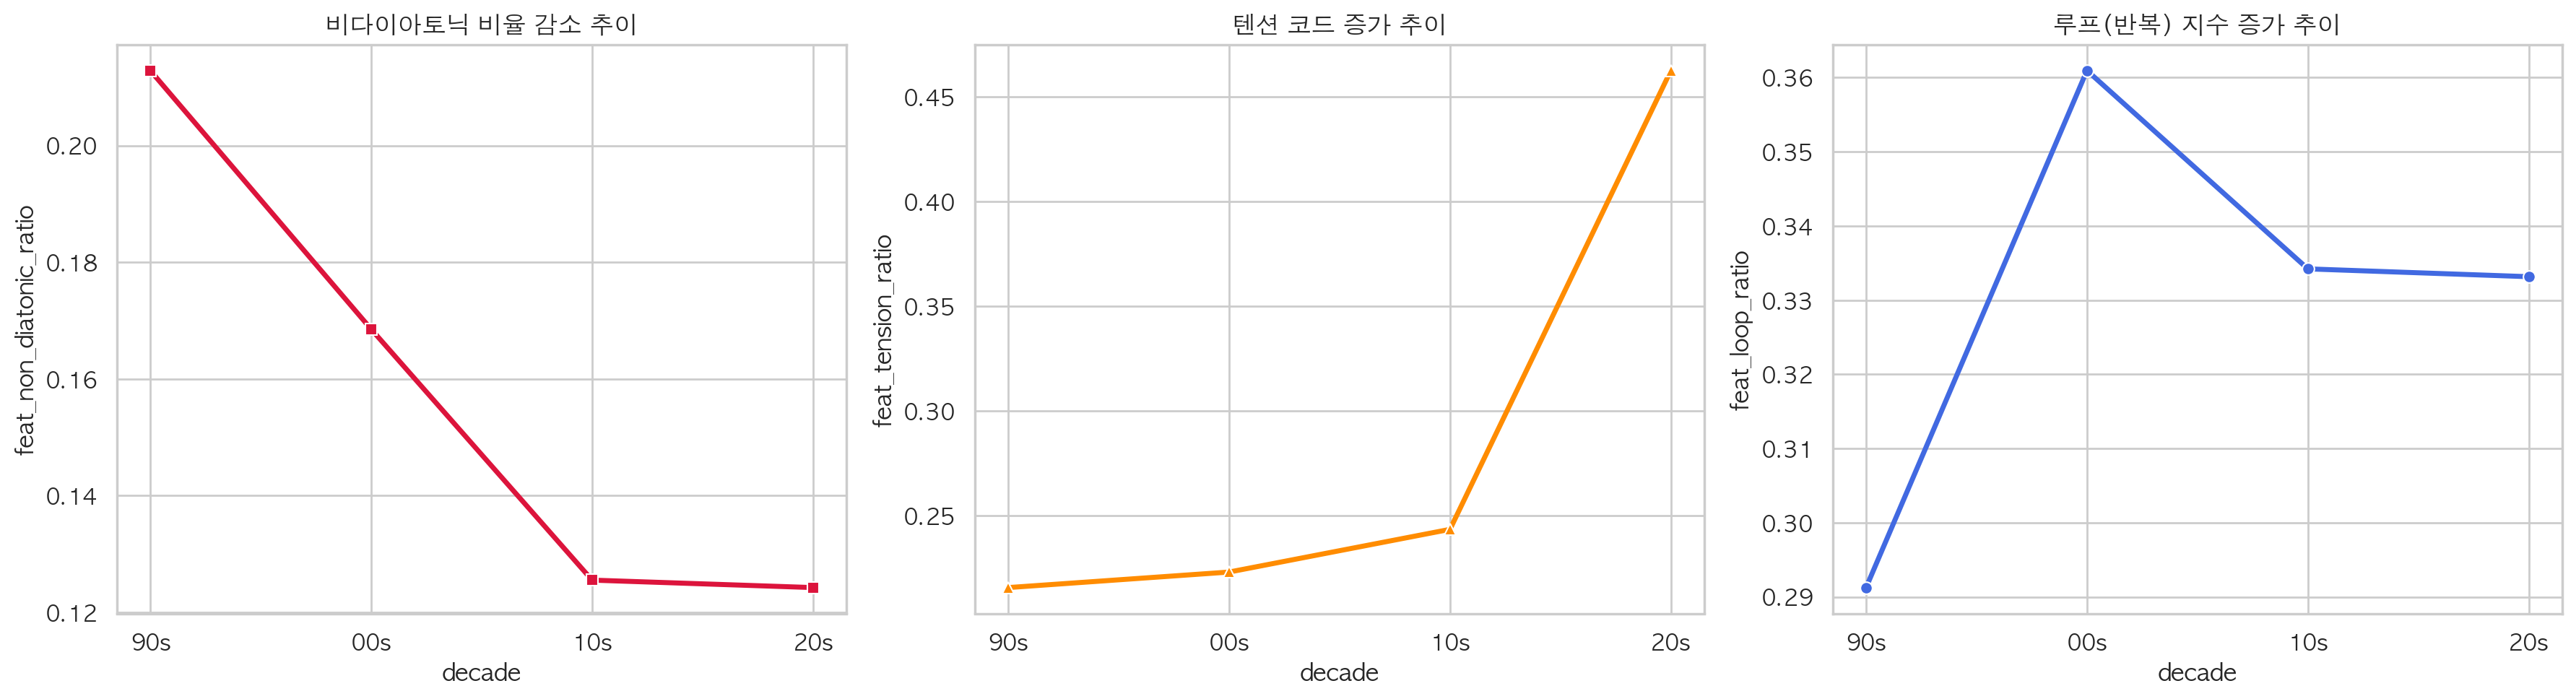

In [22]:
decade_trends = df_processed.groupby('decade')[['feat_non_diatonic_ratio', 'feat_tension_ratio', 'feat_loop_ratio']].mean().reindex(['90s', '00s', '10s', '20s'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_non_diatonic_ratio', marker='s', ax=axes[0], color='crimson', linewidth=2.5)
axes[0].set_title("비다이아토닉 비율 감소 추이", fontsize=12)
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_tension_ratio', marker='^', ax=axes[1], color='darkorange', linewidth=2.5)
axes[1].set_title("텐션 코드 증가 추이", fontsize=12)
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_loop_ratio', marker='o', ax=axes[2], color='royalblue', linewidth=2.5)
axes[2].set_title("루프(반복) 지수 증가 추이", fontsize=12)
plt.tight_layout()
plt.show()

### Phase 2. 아티스트별 화성 루프(반복) 지수 프로파일링 (Q1 보조 근거)
곡 내에서 코드를 얼마나 뱅글뱅글 반복(Loop)시키는지, 아니면 끊임없이 새로운 코드를 전개하는지는 작곡 스타일을 가르는 강력한 지표입니다.

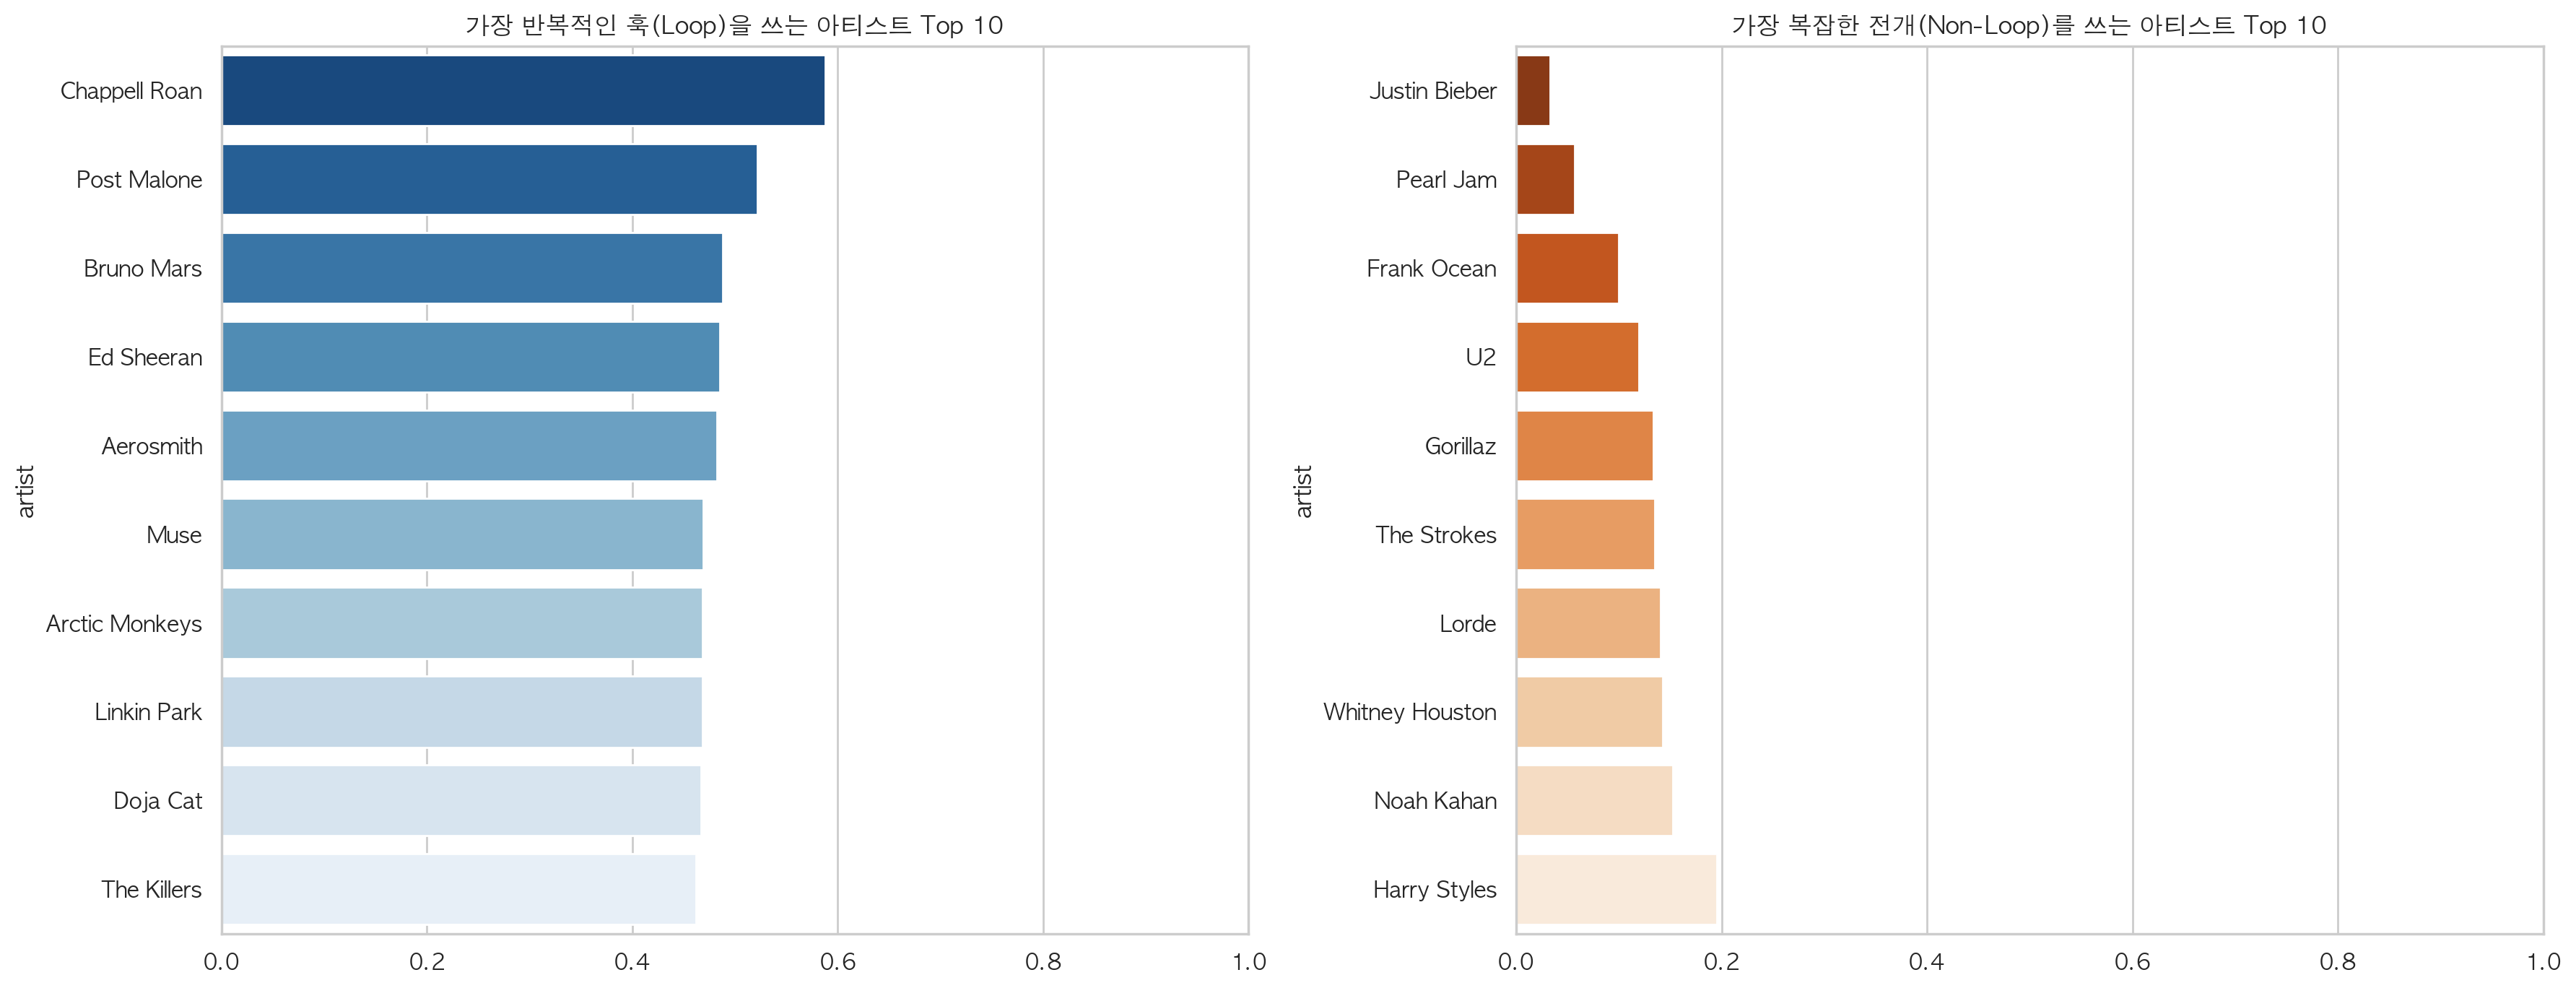

In [19]:
target_artists = df_processed['artist'].value_counts()[df_processed['artist'].value_counts() >= 5].index
loop_means = df_processed[df_processed['artist'].isin(target_artists)].groupby('artist')['feat_loop_ratio'].mean()

top_10 = loop_means.sort_values(ascending=False).head(10)
bot_10 = loop_means.sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(x=top_10.values, y=top_10.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('가장 반복적인 훅(Loop)을 쓰는 아티스트 Top 10')
axes[0].set_xlim(0, 1.0)
sns.barplot(x=bot_10.values, y=bot_10.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('가장 복잡한 전개(Non-Loop)를 쓰는 아티스트 Top 10')
axes[1].set_xlim(0, 1.0)
plt.tight_layout()
plt.show()

### Phase 3. K-Means 기반 장르 초월 군집화 (Q2의 답)
순수한 화성 피처만으로 아티스트들을 군집화합니다.

In [20]:
artist_features = df_scaled[df_scaled['artist'].isin(target_artists)].groupby('artist')[all_features].mean()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
artist_features['cluster'] = kmeans.fit_predict(artist_features)
print("✅ K-Means 군집화 완료")
print(artist_features.groupby('cluster').mean().round(3))

✅ K-Means 군집화 완료
         feat_brightness  feat_minor_ratio  feat_tension_ratio  \
cluster                                                          
0                  0.519             0.411               0.202   
1                  0.363             0.449               0.605   
2                  0.325             0.351               0.168   

         feat_non_diatonic_ratio  feat_step_motion  feat_leap_motion  \
cluster                                                                
0                          0.099             0.275             0.592   
1                          0.171             0.223             0.533   
2                          0.381             0.228             0.371   

         feat_loop_ratio  feat_unique_chords  
cluster                                       
0                  0.432               0.476  
1                  0.292               0.580  
2                  0.346               0.519  


### Phase 4. 화성적 특성의 변별력 검증 (Random Forest) 및 코사인 유사도 기반 아티스트 추천 (Q3의 답)
머신러닝 분류를 통해 화성 뼈대가 특정 아티스트를 구별할 수 있는지 확인하고, 코사인 유사도로 유사 아티스트를 탐색합니다.

Random Forest 아티스트 분류 정확도: 4.44%


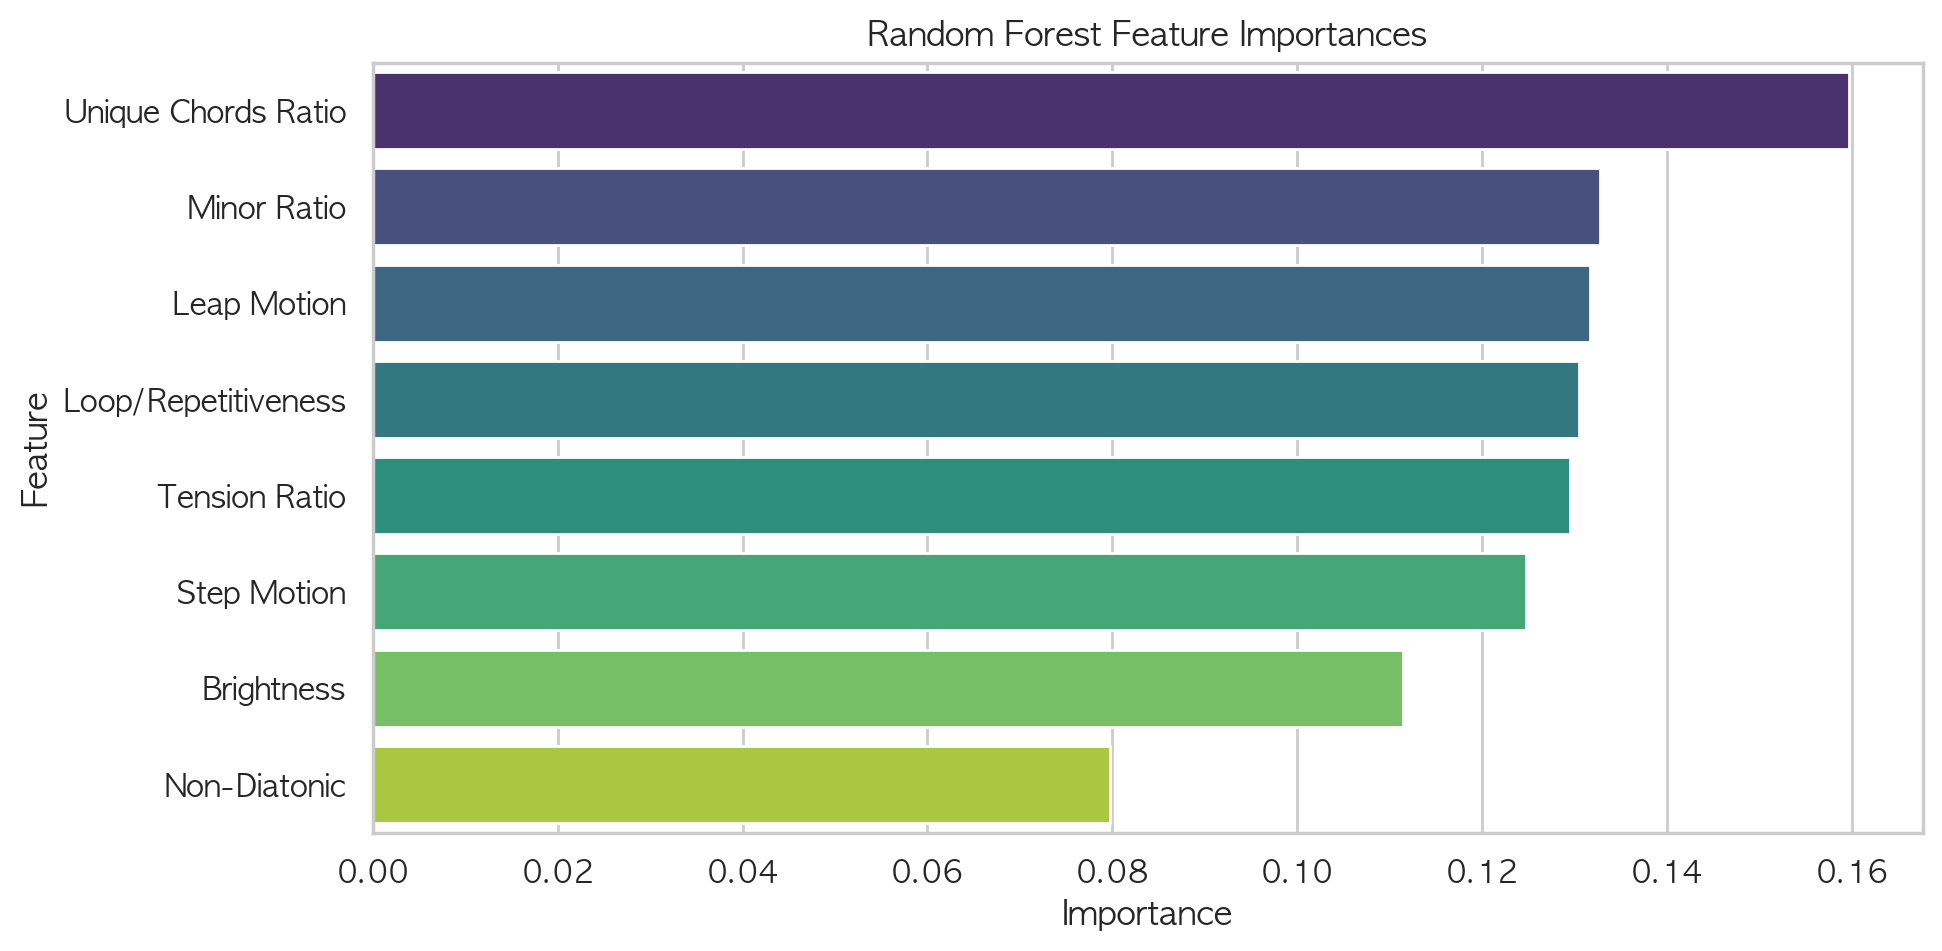

=== 코사인 유사도 기반 상위 10개 유사 아티스트 쌍 ===
Britney Spears & Nirvana : 99.63% 유사도
Avril Lavigne & Miley Cyrus : 99.62% 유사도
Dua Lipa & The Weeknd : 99.50% 유사도
Muse & Red Hot Chili Peppers : 99.43% 유사도
Arctic Monkeys & Muse : 99.40% 유사도
Miley Cyrus & Rihanna : 99.40% 유사도
Avril Lavigne & Kelly Clarkson : 99.38% 유사도
Red Hot Chili Peppers & Twenty One Pilots : 99.37% 유사도
Dua Lipa & Justin Timberlake : 99.36% 유사도
Chappell Roan & Linkin Park : 99.35% 유사도


In [21]:
# 1. Random Forest (모델 정확도 및 Feature Importance)
df_valid = df_scaled[df_scaled['artist'].isin(target_artists)].copy()
X = df_valid[all_features]
y = df_valid['artist']

# 표본이 적은 클래스 방어
valid_artists = y.value_counts()[y.value_counts() >= 4].index
df_valid = df_valid[df_valid['artist'].isin(valid_artists)]
X = df_valid[all_features]
y = df_valid['artist']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_leaf=2)
rf.fit(X_train, y_train)

print(f"Random Forest 아티스트 분류 정확도: {accuracy_score(y_test, rf.predict(X_test))*100:.2f}%")

feature_map = {
    'feat_brightness': 'Brightness', 'feat_minor_ratio': 'Minor Ratio', 'feat_tension_ratio': 'Tension Ratio',
    'feat_non_diatonic_ratio': 'Non-Diatonic', 'feat_step_motion': 'Step Motion', 'feat_leap_motion': 'Leap Motion',
    'feat_loop_ratio': 'Loop/Repetitiveness', 'feat_unique_chords': 'Unique Chords Ratio'
}
importances = pd.DataFrame({'Feature': [feature_map.get(f, f) for f in all_features], 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest Feature Importances")
plt.show()

# 2. 코사인 유사도 기반 유사 아티스트 탐색
sim_matrix = cosine_similarity(artist_features.drop('cluster', axis=1))
df_sim = pd.DataFrame(sim_matrix, index=artist_features.index, columns=artist_features.index)

print("=== 코사인 유사도 기반 상위 10개 유사 아티스트 쌍 ===")
pairs = df_sim.where(np.triu(np.ones(df_sim.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
for (a1, a2), score in pairs.head(10).items():
    print(f"{a1} & {a2} : {score*100:.2f}% 유사도")

## 5. 결론 및 한계점 (Conclusion & Limitations)

### 5.1 연구 질문별 결론
1. **Q1. 아티스트마다 고유한 화성 특징이 존재하는가?**  
   분석 결과, 아티스트별로 고유한 화성적 특징이 존재함을 확인했습니다. 특히 명도 지수(Brightness), 순차/도약 진행(Step/Leap), 루프 지수(Loop Ratio)와 같은 거시적 지표를 통해 장르적 특성과 연관된 아티스트별 화성 사용 경향을 정량적으로 관찰할 수 있었습니다.

2. **Q2. 어떤 화성 특징이 아티스트 스타일을 설명하는 데 중요한 역할을 하는가?**  
   지도학습(Random Forest) 분류 모델의 피처 중요도(Feature Importance)를 분석한 결과, 곡 내 고유 코드 비율(Unique Chords Ratio), 마이너 코드 비율(Minor Ratio), 도약 진행 비율(Leap Motion) 순으로 아티스트 스타일을 설명하는 데 중요한 역할을 하는 것으로 나타났습니다. 그러나 모델의 전체 분류 정확도는 약 4.4% 수준으로 낮았습니다. 이는 다수의 아티스트가 보편적인 코드 진행(머니코드 등)을 상당 부분 공유하고 있기 때문입니다. 즉, 화성 구조 자체만으로 특정 아티스트를 명확히 식별해 내는 데에는 한계가 있음을 확인했습니다.

3. **Q3. 코드 진행 특징만으로 유사한 음악적 스타일을 가진 아티스트를 탐색할 수 있는가?**  
   분류 모델의 한계를 보완하기 위해 아티스트 간 화성 벡터의 코사인 유사도(Cosine Similarity)를 측정한 결과, 내용 기반(Content-Based) 추천의 가능성을 확인했습니다. (예: Dua Lipa & Justin Timberlake 등 유사한 화성 전개를 가진 아티스트 탐색). 이는 장르나 인기 지표에 의존하지 않고, 곡의 화성학적 구조만으로 유사한 스타일을 추천하는 시스템의 보조 지표로 활용될 수 있음을 시사합니다.

### 5.2 기대효과
- **음악 추천 시스템**: 인기도나 사용자 협업 필터링(Collaborative Filtering) 중심의 기존 추천 알고리즘을 보완하여, 화성 구조 중심의 추천 기준을 추가로 제공할 수 있습니다.
- **아티스트 스타일 정량화**: 아티스트별 화성 특징을 수치화하여 객관적으로 비교하는 분석 틀을 제공합니다.

### 5.3 한계점
- **데이터 편향**: 공개 크라우드소싱 기반 데이터 특성상 특정 장르와 아티스트에 편향이 존재할 수 있습니다.
- **분석 범위의 한계**: 본 연구는 멜로디, 리듬, 음색, 가사 등을 제외하고 화성(Harmony) 구조 정보만 한정적으로 활용했습니다.